# Descomposición STL

En este notebook vamos a descomponer la serie para cuantificar estacionalidad, aislar tendencia si es que hay y ver como se comporta el residuo, que será un dato importante para evaluar el comportamiento de la serie con el precio regular y las promociones.

Tal cómo se determinó en el primer notebook, vamos a trabajar solo con un producto y eliminar las primeras fases de la serie.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import boxcox

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

## Carga de datos

In [2]:
pepsi = pd.read_parquet('../data/processed/pepsi_2l.parquet')

print(pepsi.shape)
print(pepsi['start'].min(), ';',  pepsi['start'].max())
print(f'Tiendas: {pepsi["STORE"].nunique()}')

(31751, 15)
1989-09-14 00:00:00 ; 1997-05-01 00:00:00
Tiendas: 93


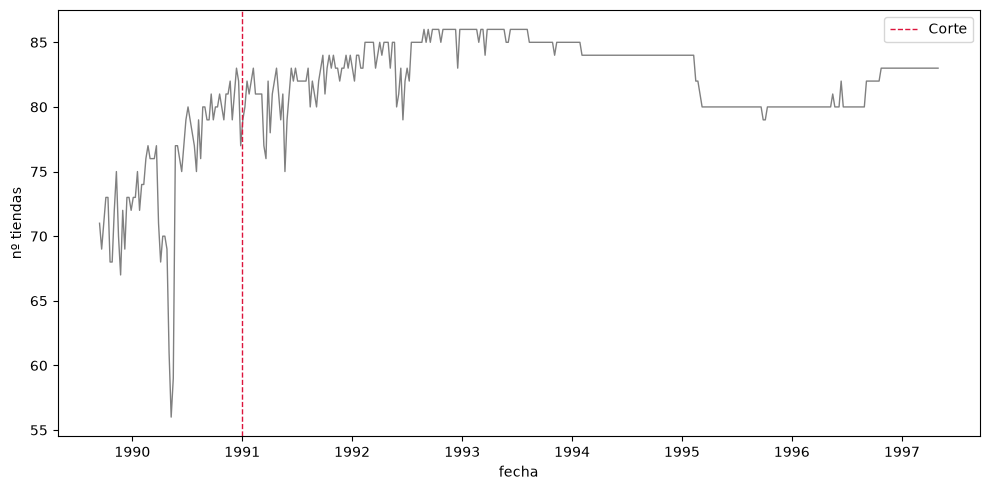

In [3]:
cov = (pepsi.groupby('start')
       .agg(unidades=('MOVE', 'sum'), n_tiendas=('STORE', 'nunique'))
       .reset_index().sort_values('start'))

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(cov['start'], cov['n_tiendas'], lw=1, color='gray')
ax.axvline(pd.Timestamp('1991-01-01'), color='crimson', ls='--', lw=1, label='Corte')
ax.set(xlabel='fecha', ylabel='nº tiendas')

ax.legend()
plt.tight_layout()
plt.show()

Confirmamos visualmente la estabilidad de tiendas.

In [4]:
START = '1991-01-01'  # punto de corte

pepsi_corte = pepsi[pepsi['start'] >= START].copy()

serie = (pepsi_corte.groupby('start')
         .agg(unidades_tot=('MOVE', 'sum'), n_tiendas=('STORE', 'nunique'))
         .reset_index().sort_values('start'))

serie['media_por_tienda'] = serie['unidades_tot'] / serie['n_tiendas']

serie.head()

,start,unidades_tot,n_tiendas,media_por_tienda
0,1991-01-03,14859,79,188.088608
1,1991-01-10,32247,80,403.087500
2,1991-01-17,12822,82,156.365854
3,1991-01-24,12849,81,158.629630
4,1991-01-31,24056,82,293.365854


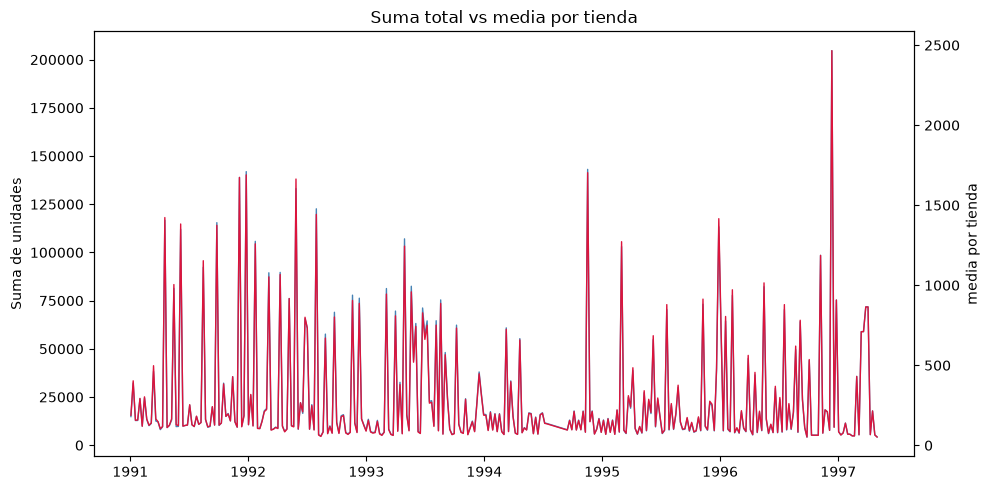

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(serie["start"], serie["unidades_tot"], color="steelblue", lw=1, label="suma total")
ax1.set(title='Suma total vs media por tienda', ylabel='Suma de unidades')
ax2 = ax1.twinx()
ax2.plot(serie["start"], serie["media_por_tienda"], color="crimson", lw=1, label="media por tienda")
ax2.set_ylabel("media por tienda")

plt.tight_layout()
plt.show()

Como el número de tiendas que reportan ventas no es constante en el tiempo, la suma de unidades confundiría dos cosas: la demanda real y el número de tiendas que la registran. Para evitarlo usamos la media de unidades por tienda, que refleja el nivel de demanda típico por tienda con independencia de cuántas tiendas haya esa semana.

En la práctica, tras recortar el periodo inicial la cobertura es estable, por lo que suma y media por tienda evolucionan casi en paralelo; usamos la media por robustez, aunque en esta ventana la diferencia es menor.

## Construcción de serie única
Para realizar la descomposición `STL`, necesitamos una serie temporal regular y sin espacios vacíos. En esta fase vamos a construir la serie para rellenar los huecos vacios presentes.

In [6]:
s = serie.set_index('start')['media_por_tienda'].sort_index().asfreq('7D') # reindexamos serie y establecemos frecuencia

print(f'Semanas en la ventana: {len(s)}')
print(f'Semanas ausentes: {s.isna().sum()}')

Semanas en la ventana: 331
Semanas ausentes: 9


In [7]:
s[s.isna()] # fechas sin datos

start
1993-11-18   NaN
1994-07-21   NaN
1994-07-28   NaN
1994-08-04   NaN
1994-08-11   NaN
1994-08-18   NaN
1994-08-25   NaN
1994-09-01   NaN
1994-09-08   NaN
Name: media_por_tienda, dtype: float64

Como hemos visto anteriormente, la serie parece ser `multiplicativa`, por lo que conviene aplicar un logaritmo sobre la misma para transformarla en `aditiva` y que resulte mucho más sencillo trabajar. Antes de aplicar la transformación solo por efecto visual, vamos aplicar `Box-Cox` para confirmar la transformación en base a la máxima verosimilitud. 

Para ello vamos a eliminar los registros que se encuentran vacíos, evitando de esta forma posibles errores en el cálculo. Estos registros vacíos serán interpolados más adelante, ya que para realizar la descomposición `STL` necesitamos que todos los datos estén completos.

In [8]:
# Limpiamos valores ausentes
s_clean = s.dropna()

_, lam = boxcox(s_clean.values)
print(f'Lambda óptimo de Box-Cox: {lam:.4f}')

Lambda óptimo de Box-Cox: -0.6033


El resultado de lambda óptimo se encuentra muy alejado de 0, lo que sería un problema para aplicar el logaritmo a los datos. Antes de descartar nada, como la serie se encuentra muy influenciada por los picos de ventas promocionales, vamos a eliminar estos picos de la serie y volver a calcular.

In [9]:
# Eliminamos picos de la serie
q99 = s_clean.quantile(0.99)

s_sin_picos = s_clean[s_clean <= q99]
_, lam_sin = boxcox(s_sin_picos.values)
print(f'Lambda sin el 1% superior: {lam_sin:.3f}')

Lambda sin el 1% superior: -0.612


Tras eliminar los picos, el lambda óptimo sigue sin mejorar. Es importante tener en cuenta que `Box-Cox` optimiza la normalidad, no la estabilización de la varianza que se necesita para una descomposición aditiva. El valor de lambda que nos devuelve la transformación ocurre cuando la serie tiene muchos valores pequeños y una cola larga hacia arriba. 

Para intentar solventar el problema vamos a ver como se comporta la dispersión de la serie. Antes de continuar, importante resaltar la diferencia entre serie `aditiva` y `multiplicativa`. 
- En una serie aditiva, las subidas y bajadas tienen el mismo tamaño absoluto independientemente del nivel.
- En una serie multiplitcativa, las fluctuaciones crecen con el nivel, por tanto son un pocentaje del nivel no una cantidad fija.

En este caso, la dispersión es una forma de medir si esa relación de fluctuación existe realmente.

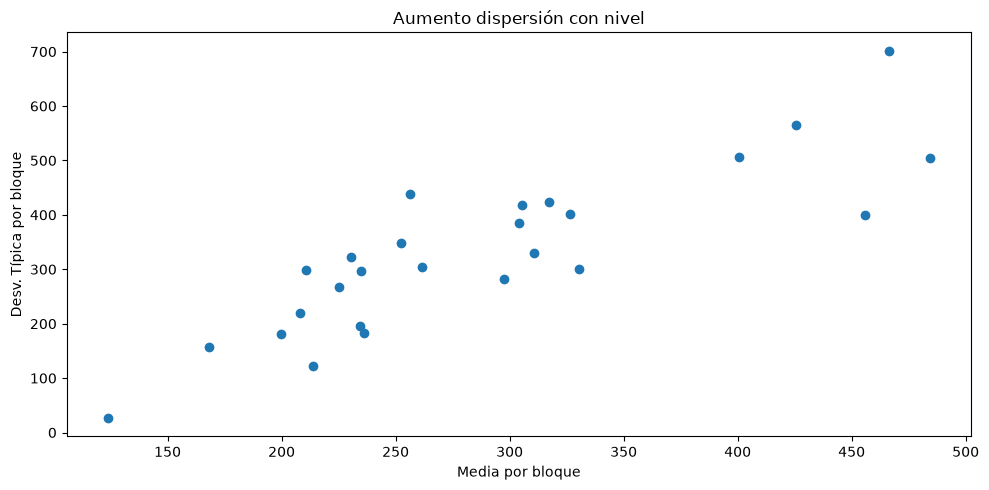

Correlación media-dispersión: 0.8603


In [10]:
# Creamos distintos bloques
bloques = pd.DataFrame(
    {'y': s_clean.values}, index=s_clean.index
    ).resample('13W')['y'].agg(['mean', 'std']).dropna() # partimos la serie en tramos de 13 semanas. Aproximadamente un trimestre

fig, ax = plt.subplots(figsize=(10,5))

ax.scatter(bloques['mean'], bloques['std'])
ax.set(title='Aumento dispersión con nivel', xlabel='Media por bloque', ylabel='Desv. Típica por bloque')

plt.tight_layout()
plt.show()

print(f"Correlación media-dispersión: {bloques.corr().loc['mean', 'std']:.4f}")

Podemos ver como los puntos crecen diagonalmente y muestran correlación positiva (0.8603), por tanto la serie es multiplicativa, la dispersión crece con el nivel y el log es la transformación adecuada para la serie.

Para esta serie, la transformación `Box-Cox` simplemente no era la adecuada, debido a que optimiza la normalidad de la distribución y no la estabilzación de la varianza, que es lo que se necesita para la descomposición aditiva. Este proceso nos ha servido para entender un poco más como se comporta la propia serie. Aunque aplicar logaritmo visualmente parecía ser el proceso adecuado, comprobarlo numéricamente fue la opción correcta. De esta forma, al aplicar logaritmo a los datos, ya iniciamos el proceso de conexión con la elasticidad que se calcula empleando el logaritmo y que se desarrolla en los siguientes notebooks.

A continuación vamos a aplicar el logaritmo e interpolar los valores ausentes.

In [11]:
log_s = np.log(s) # aplicamos log
log_s = log_s.interpolate(method='time') # rellenamos espacios vacíos

print(f'Ausentes tras interpolar: {log_s.isna().sum()}')

Ausentes tras interpolar: 0


## STL

8.881784197001252e-16


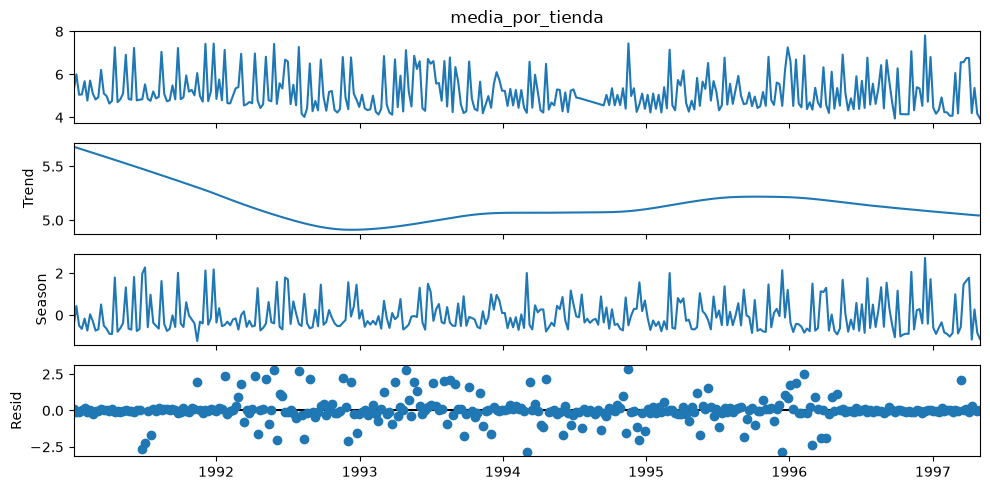

In [12]:
stl = STL(
    log_s,
    period=52, # indicamos periodo de 52 semanas para que sea capaz de diferenciar años
    robust=True
)

result = stl.fit() # ajustamos modelo

dcmp = pd.DataFrame({ #dcmp = descomposition
    "ds": log_s.index,
    "data": log_s,
    "trend": result.trend,
    "seasonal": result.seasonal,
    "remainder": result.resid,
}).reset_index(drop=True)

# Nos aseguramos que la descomposición vuelven a reconstruir la serie.
print((dcmp["data"] - (dcmp["trend"] + dcmp["seasonal"] + dcmp["remainder"])).abs().max()) # debe ser próximo a 0.

fig = result.plot()

fig.set_size_inches(10,5)
plt.tight_layout()
plt.show()



Observando el gráfico de la descomposición obtenemos las siguientes conclusiones:
- La tendencia capturada es limpia y legible, cae con claridad al inicio de la serie. luego empieza a recuperarse y termina aplanandose. La tendencia es suave. 
- En cuanto a la estacionalidad, está no es capturada de forma limpia, los picos de la serie no reflejan periodos estacionales claros como podría ser invierno/verano. En esta serie no se está repitiendo cada año el mismo patrón. Lo que ocurre es que al forzar period=52, la descomposición está metiendo parte de la señal promocional en la estación porque algunas promociones se repiten en fechas similares cada año y el STL las interpreta como patrón anual.
- Observando los residuos,salvo por eciertos puntos, se encuentra bastante centrado. Es aquí donde se detecta el problema, al estar tan centrado, nos indica que las promociones no se están capturando en el residuo sino que se han trasladado a la estacionalidad.

La descomposición no sale limpia porque la principal fuente de variación de la serie, que son las promociones, no es ninguna de las 3 componentes pertenecientes a la descomposición. Hasta aquí, el método `STL` ha cumplido su función.

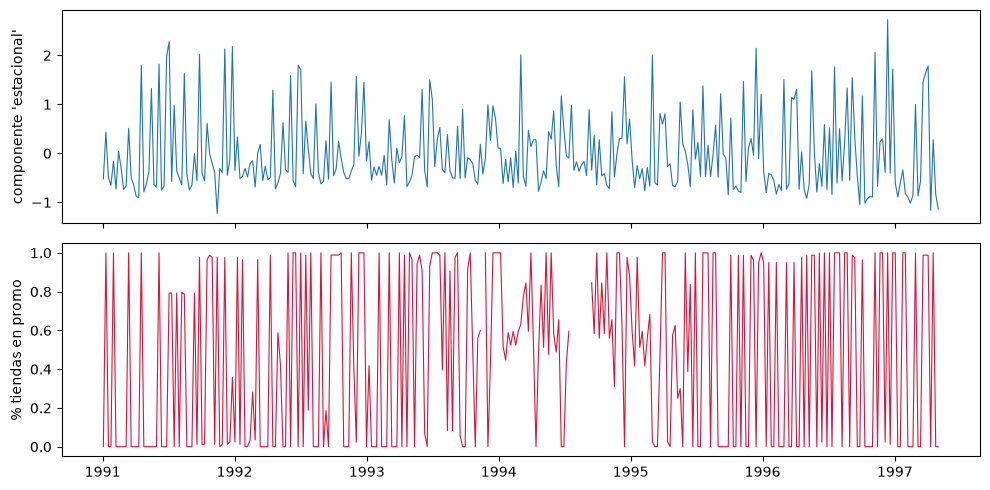

Correlación: 0.3113


In [ ]:
# Fracción de tiendas en promoción por semana (sobre la ventana ya recortada)
promo_sem = (pepsi_corte.assign(promo=pepsi_corte["SALE"].notna()) # obtenemos valores dummy para los días de promo
             .groupby("start")["promo"].mean())
dcmp = dcmp.merge(promo_sem.rename("frac_promo"), left_on="ds", right_index=True, how="left")

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(dcmp["ds"], dcmp["seasonal"], lw=0.8)
ax[0].set_ylabel("componente 'estacional'")
ax[1].plot(dcmp["ds"], dcmp["frac_promo"], lw=0.8, color="crimson")
ax[1].set_ylabel("% tiendas en promo")

plt.tight_layout()
plt.show()

print(f'Correlación: {dcmp[["seasonal", "frac_promo"]].corr().iloc[0, 1]:.4f}')

Contruimos una serie nueva para incluir si cada semana tiene o no promoción. Con esa nueva columna creada dentro de la variable `dcmp`, procedemos a graficar la componente estacional y el porcentaje de tiendas con promo. La idea es ver si suben y bajan a la vez ambas series, pero el resultado no es muy esclarificador. Para intentar aclararnos un poco más, calculamos la correlación (0.3113) entre ambas series, que resulta ser positiva aunque moderada.

La correlación entre la componente estacional y la intensidad promocional es positiva pero moderada (0,31); es coherente con que la promoción infle la estacional, aunque la relación se diluye porque la estacional es periódica y las promociones no.

Para intentar zanjar este asunto, vamos a calcular la media de la estacionalidad y residuo para las semanas con promoción y las semanas sin promoción.

In [14]:
dcmp["promo_bin"] = dcmp["frac_promo"] > 0.5
dcmp.groupby("promo_bin")[["seasonal", "remainder"]].agg(["mean", "std"])

seasonal           remainder          
               mean       std      mean       std
promo_bin                                        
False     -0.210331  0.715131 -0.199482  0.745671
True       0.209190  0.818555  0.308648  0.901370

La interpretación para este resultado es:
- Cuando no hay promoción, tanto la estacionalidad como el residuo son negativos, lo que indica que la demanda está por debajo de su nivel normal.
- Por el contrario cuando hay promoción, ambos valores son positivos. Por tanto la promoción empuja la demanda hacia arriba y ese empuje se reparte entre estacionalidad y residuo
